# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

In [31]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

data_path = Path("../../data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt")

df = load_txt(data_path)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3533 entries, 0 to 3532
Columns: 1012 entries, Mean_intensity_3rd-Ventricle_whole-brain to ID
dtypes: float64(1011), str(1)
memory usage: 27.3 MB


In [24]:
X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2)

In [25]:
from torch.utils.data import DataLoader

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=32, shuffle=False)

In [26]:
from model import DNN

model = DNN(input_dim=X_train.shape[1], hidden_dims=[64, 64, 64], output_dim=1)
print(model)

DNN(
  (network): Sequential(
    (0): Linear(in_features=1010, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [27]:
from torch import nn, optim
import torch

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses = []
test_losses = []
 
for epoch in range(200):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    model.eval()
    test_loss = 0
    criterion = nn.MSELoss()
 
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Mean Squared Error: {average_test_loss:.4f}")

Epoch 1, Loss: 1550.2906
Test Mean Squared Error: 17.1578
Epoch 2, Loss: 1217.9847
Test Mean Squared Error: 18.1082
Epoch 3, Loss: 1023.4790
Test Mean Squared Error: 17.1046
Epoch 4, Loss: 839.1553
Test Mean Squared Error: 17.5016
Epoch 5, Loss: 729.9588
Test Mean Squared Error: 16.8586
Epoch 6, Loss: 580.8359
Test Mean Squared Error: 17.3848
Epoch 7, Loss: 547.6890
Test Mean Squared Error: 16.5323
Epoch 8, Loss: 465.7011
Test Mean Squared Error: 17.6555
Epoch 9, Loss: 435.1023
Test Mean Squared Error: 21.9475
Epoch 10, Loss: 332.8191
Test Mean Squared Error: 19.2849
Epoch 11, Loss: 331.6447
Test Mean Squared Error: 21.4996
Epoch 12, Loss: 245.6381
Test Mean Squared Error: 17.7247
Epoch 13, Loss: 279.0001
Test Mean Squared Error: 17.6601
Epoch 14, Loss: 277.0199
Test Mean Squared Error: 18.8604
Epoch 15, Loss: 245.2805
Test Mean Squared Error: 19.0992
Epoch 16, Loss: 185.5961
Test Mean Squared Error: 17.7091
Epoch 17, Loss: 193.4068
Test Mean Squared Error: 19.0700
Epoch 18, Loss: 213.

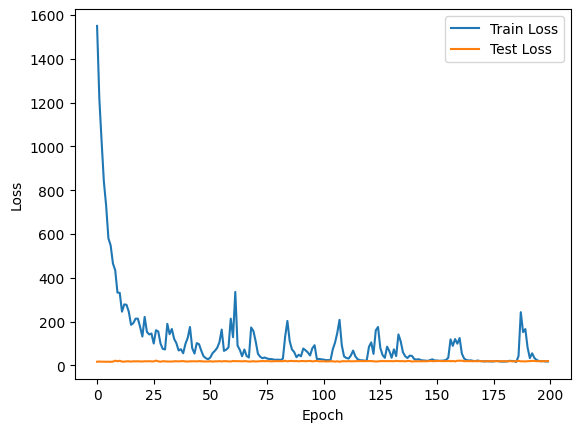

In [28]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()